# Detecting Negative Company News

**Author:** Mauro Reverberi

**Program:** MSc AI, Udacity Institute of AI & Technology / Woolf

**Project:** Capstone Project 4, Deep Learning Systems

**Dataset:** Financial PhraseBank v1.0 (Malo et al., 2014), license CC BY-NC-SA 3.0:
https://huggingface.co/datasets/takala/financial_phrasebank

In this notebook I fine-tune a pretrained Transformer (DistilBERT) in PyTorch that reads one sentence of company news and decides whether it is negative, neutral or positive for an investor. The output is one probability per class.

**Research question:** How well can a fine-tuned Transformer recognize negative news about a company, and does a loss that gives the rare negative class more weight help to find more of it?

I picked this problem because it connects to my earlier capstone projects. In Project 1 I built a cleaned dataset of Swiss legal entities from the GLEIF register, in Project 2 I analyzed new company registrations and in Project 3 I turned a bankruptcy score into a screening decision. A later capstone project will build a due diligence agent that checks a company. One standard step of such a check is adverse media screening, reading the news about a company and flagging the negative items. An analyst reads the flagged items, so I assume that a missed negative item costs more than an extra one to review. One point up front, the labels measure the view of an investor, so a negative sentence here is not yet adverse media in the compliance sense.

## Problem definition and dataset

**Task type:** supervised learning, text classification with three classes. The observation unit is one sentence, and the label says whether it is negative, neutral or positive for an investor. I fine-tune the pretrained encoder `distilbert-base-uncased` with my own classification head in PyTorch.

**Dataset:** Malo et al. (2014) collected sentences from English financial news about companies, many of them Finnish. Five to eight of 16 annotators with a background in finance labeled every sentence. The release has four files with more than 50%, 66%, 75% and full agreement. I use all sentences with more than 50% agreement and keep the agreement level as an extra column (50-65%, 66-74%, 75-99%, 100%), so I can check later whether the model struggles where the annotators did not agree. The sentences are real news text, nothing is synthetic, and the license allows academic, non-commercial use. I did not use this source in my earlier capstone projects.

4,836 sentences are too few to train a Transformer from scratch, but pretrained encoders like BERT are often fine-tuned on a few thousand examples. My training split has 3,393 sentences.

`prepare_dataset.py` downloads the archive from a fixed revision on Hugging Face, removes repeated and contradictory sentences and adds the agreement level. Sentences of the same template with other amounts or years go into one group, either because they have the same letters once everything else is removed or because their TF-IDF similarity is at least 0.65. This gives 123 groups with more than one sentence, 338 sentences in total, and every other sentence forms a group of its own. The script splits the groups about 70/15/15 into train, validation and test, stratified by the label and agreement level of the first sentence of each group. I downloaded the archive on 2026-10-01, the result `phrasebank.csv` is included.

## Setup

If CUDA is available I use it, otherwise the CPU. Seed 42 is the main seed of the notebook.

In [1]:
import copy
import os
import random
import time

# only needed on an NVIDIA GPU, there the deterministic algorithms need a fixed cuBLAS workspace
os.environ.setdefault("CUBLAS_WORKSPACE_CONFIG", ":4096:8")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
import huggingface_hub
import transformers
from transformers import AutoModel, AutoTokenizer
from scipy import stats
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, confusion_matrix, f1_score,
                             precision_score, recall_score)
from sklearn.metrics.pairwise import cosine_similarity

In [2]:
sns.set_theme(style="whitegrid")
transformers.logging.set_verbosity_error()
transformers.logging.disable_progress_bar()
huggingface_hub.logging.set_verbosity_error()
os.environ["TOKENIZERS_PARALLELISM"] = "false"
torch.use_deterministic_algorithms(True)

In [3]:
DATA_FILE = "phrasebank.csv"
LABELS = ["negative", "neutral", "positive"]
MAIN_SEED = 42
SEEDS = [42, 43, 44, 45, 46]
MAX_TOKENS = 160
MODEL_NAME = "distilbert-base-uncased"
# fixed commit of the model repository on the Hugging Face hub, for encoder and tokenizer
MODEL_REVISION = "12040accade4e8a0f71eabdb258fecc2e7e948be"
BATCH_SIZE = 32
EPOCHS = 5
LEARNING_RATE = 2e-5
WEIGHT_DECAY = 0.01

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"device: {device}")

device: cpu


In [5]:
def set_seed(seed):
    """Set the seed of random, NumPy and PyTorch, so a run can be repeated."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

set_seed(MAIN_SEED)

## Load the dataset

I load the prepared file, one row per sentence, and check the structure before I touch anything.

In [6]:
sentences = pd.read_csv(DATA_FILE)
sentences["split"] = pd.Categorical(sentences["split"], ["train", "validation", "test"])
sentences["agreement"] = pd.Categorical(sentences["agreement"], ["50-65%", "66-74%", "75-99%", "100%"])
sentences["label_id"] = sentences["label"].map({label: i for i, label in enumerate(LABELS)})
print(f"Rows: {sentences.shape[0]:,}, columns: {sentences.shape[1]}")

Rows: 4,836, columns: 6


In [7]:
sentences.info()

<class 'pandas.DataFrame'>
RangeIndex: 4836 entries, 0 to 4835
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype   
---  ------     --------------  -----   
 0   sentence   4836 non-null   str     
 1   label      4836 non-null   str     
 2   agreement  4836 non-null   category
 3   group      4836 non-null   int64   
 4   split      4836 non-null   category
 5   label_id   4836 non-null   int64   
dtypes: category(2), int64(2), str(2)
memory usage: 161.0 KB


In [8]:
sentences.head()

,sentence,label,agreement,group,split,label_id
0,"According to Gran , the company has no plans t...",neutral,100%,0,test,1
1,Technopolis plans to develop in stages an area...,neutral,66-74%,1,validation,1
2,The international electronic industry company ...,negative,50-65%,2,train,0
3,With the new production plant the company woul...,positive,75-99%,3,validation,2
4,According to the company 's updated strategy f...,positive,66-74%,4,test,2


The file has 4,836 rows, the five columns from the preparation and `label_id`, the label as a number for the loss (0 negative, 1 neutral, 2 positive). No value is missing. The sentences were apparently tokenized before they were published, with spaces around punctuation like `Gran ,` and `company 's`. `group` is the template group that the preparation uses for the split.

## Data checks

Before I model anything I want to see what the sentences look like, how the three labels are spread, how strongly the annotators agreed and whether the text has quality problems.

In [9]:
pd.set_option("display.max_colwidth", 150)
sentences.groupby("label").sample(2, random_state=MAIN_SEED)[["label", "agreement", "sentence"]]

,label,agreement,sentence
3780,negative,50-65%,The company decided at the end of 2008 to temporarily shut down its ammonia plant in Billingham and extend the maintenance period at its Ince faci...
4660,negative,100%,down to EUR5 .9 m H1 '09 3 August 2009 - Finnish media group Ilkka-Yhtyma Oyj ( HEL : ILK2S ) said today its net profit fell 45 % on the year to E...
1181,neutral,100%,BasWare Order Matching automatically matches purchase invoices with approved purchase orders .
3916,neutral,75-99%,"The total value of the project is estimated to be over 3.0 mln euro $ 4.4 mln , of which the services will be over 2.0 mln euro $ 2.9 mln and thir..."
957,positive,100%,Operating profit improved by 44.0 % to ER 4.7 mn from EUR 3.3 mn in 2004 .
778,positive,66-74%,Stora Enso owns 43 percent of Bergvik and earns therefore SEK 1.5 bn on the value appreciation .


The examples show the task. With full agreement, the negative sentence reports a net profit that fell 45% and the positive one an operating profit that improved by 44%. The negative sentence with only 50-65% agreement is about a plant that is shut down for a while, which an investor could also read as normal maintenance. The neutral sentences describe a product and the value of a project without judging them. One sentence writes `ER 4.7 mn` instead of `EUR 4.7 mn`, a typo in the source.

In [10]:
table = pd.crosstab(sentences["agreement"], sentences["label"], margins=True)
print(table)

label      negative  neutral  positive   All
agreement                                   
50-65%           90      342       195   627
66-74%           94      388       279   761
75-99%          117      755       317  1189
100%            303     1386       570  2259
All             604     2871      1361  4836


In [11]:
shares = pd.crosstab(sentences["split"], sentences["label"], normalize="index").round(3)
print(shares)

label       negative  neutral  positive
split                                  
train          0.126    0.594     0.280
validation     0.123    0.596     0.280
test           0.120    0.589     0.291


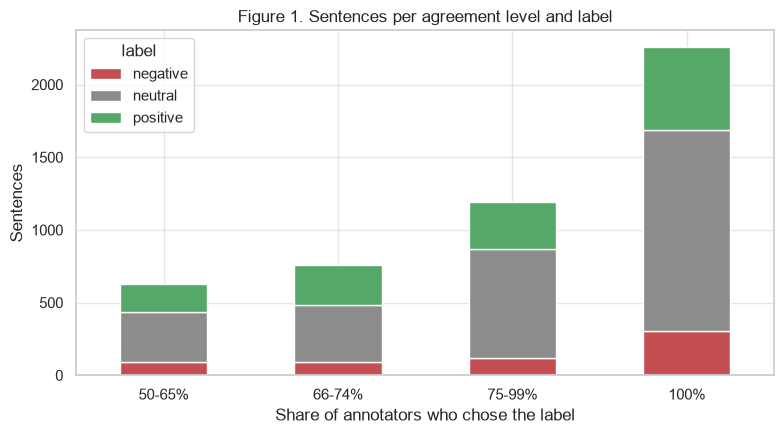

In [12]:
counts = pd.crosstab(sentences["agreement"], sentences["label"])[LABELS]
fig, ax = plt.subplots(figsize=(8, 4.5))
counts.plot.bar(stacked=True, ax=ax, rot=0, color=["C3", "C7", "C2"])
ax.set_title("Figure 1. Sentences per agreement level and label")
ax.set_xlabel("Share of annotators who chose the label")
ax.set_ylabel("Sentences")
ax.legend(title="label")
plt.tight_layout()
plt.show()

**Interpretation:** 2,871 sentences (59.4%) are neutral, 1,361 (28.1%) positive and only 604 (12.5%) negative. The stratified split keeps these shares within about one percentage point in all three splits. Figure 1 shows that the annotators fully agreed on 2,259 sentences (46.7%). Below 75% agreement 34.1% of the sentences are positive, with full agreement only 25.2%. A model that always answers "neutral" would be right on 58.9% of the test sentences, so accuracy alone says little.

In [13]:
# words with a "+" in front of a non-ASCII character are broken letters, for example "Sepp+ñl+ñ"
broken = sentences["sentence"].str.contains(r"\+[^\x00-\x7f]")
print(f"sentences with broken letters: {broken.sum()} ({broken.mean():.1%})")
print(sentences.loc[broken, "sentence"].str.extract(r"(\S*\+[^\x00-\x7f]\S*)")[0].head(6).tolist())

sentences with broken letters: 93 (1.9%)
['Sepp+ñl+ñ', 'Brand+úo', '+àland', 'L+ñnnen', 'Sepp+ñl+ñ', '+àland']


In [14]:
words = sentences["sentence"].str.split().str.len()
print(f"words per sentence: median {words.median():.0f}, shortest {words.min()}, longest {words.max()}")

numbers = sentences["sentence"].str.contains(r"\d")
print(f"sentences with at least one number: {numbers.mean():.1%}")

words per sentence: median 21, shortest 2, longest 81
sentences with at least one number: 53.3%


In [15]:
print(sentences.groupby("label")["sentence"].apply(lambda s: s.str.contains(r"\d").mean()).round(3))

label
negative    0.753
neutral     0.467
positive    0.577
Name: sentence, dtype: float64


My check finds one recurring form of broken letters in 93 sentences (1.9%). Other encoding errors, such as `-¦` for an apostrophe, are not covered by this check. `Sepp+ñl+ñ` is the Finnish name Seppälä and `+àland` is Åland, so a letter outside ASCII became a plus and another character. My guess is an old encoding error, UTF-8 text that was read once with a DOS code page. The frequent cases could be mapped back, but a few rare patterns do not give a clear letter. I keep all these sentences as they are, so the data has no mix of repaired and broken names. The broken words are mostly company and place names, not the words that carry the sentiment.

The sentences are short, a median of 21 words, the longest has 81. 75.3% of the negative sentences contain a number, against 46.7% of the neutral ones. That fits the examples above, many negative sentences report a fall of profit or sales in figures.

In [16]:
# the preparation keeps every template group in one split, I check this first
group_sizes = sentences["group"].value_counts()
splits_per_group = sentences.groupby("group")["split"].nunique()
print(f"Template groups with more than one sentence: {(group_sizes > 1).sum()}")
print(f"Template groups in more than one split: {(splits_per_group > 1).sum()}")

Template groups with more than one sentence: 123
Template groups in more than one split: 0


In [17]:
def closest_sentence(queries, pool):
    """Return the highest TF-IDF cosine similarity and the closest pool sentence for every query sentence."""
    vectorizer = TfidfVectorizer(ngram_range=(1, 2), sublinear_tf=True)
    pool_vectors = vectorizer.fit_transform(sentences.loc[pool, "sentence"])
    query_vectors = vectorizer.transform(sentences.loc[queries, "sentence"])
    similarity = cosine_similarity(query_vectors, pool_vectors)
    return similarity.max(axis=1), sentences.index[pool][similarity.argmax(axis=1)]

In [18]:
# an exact twin is the same sentence once everything except the letters is removed
letters_only = sentences["sentence"].str.lower().str.replace(r"[^a-z]", "", regex=True)
is_train = sentences["split"] == "train"
is_validation = sentences["split"] == "validation"
is_test = sentences["split"] == "test"

checks = [("test against train and validation", is_test, ~is_test),
          ("validation against train", is_validation, is_train)]
closest = {}
for name, queries, pool in checks:
    exact_twins = letters_only[queries].isin(set(letters_only[pool])).sum()
    similarity, nearest = closest_sentence(queries, pool)
    closest[name] = similarity, nearest
    print(f"{name}: exact twins {exact_twins}, similarity >= 0.8: {(similarity >= 0.8).sum()}, "
          f"highest similarity {similarity.max():.2f}")

# the five closest pairs between test and the other two splits
similarity, nearest = closest["test against train and validation"]
# the index is the row number of the test sentence in the dataset
closest_pairs = pd.DataFrame({
    "similarity": similarity.round(2),
    "test sentence": sentences.loc[is_test, "sentence"].to_numpy(),
    "closest train or validation sentence": sentences.loc[nearest, "sentence"].to_numpy(),
}, index=sentences.index[is_test])
closest_pairs.sort_values("similarity", ascending=False).head(5)

test against train and validation: exact twins 0, similarity >= 0.8: 0, highest similarity 0.77
validation against train: exact twins 0, similarity >= 0.8: 0, highest similarity 0.78


,similarity,test sentence,closest train or validation sentence
173,0.77,"Both operating profit and turnover for the six-month period increased , respectively from EUR0 .1 m and EUR29 .0 m , as compared to the correspond...","Both operating profit and turnover for the nine-month period increased , respectively from EUR2 .4 m and EUR43 .8 m , as compared to the correspon..."
166,0.74,"Both operating profit and net sales for the six-month period increased , respectively from EUR18 .1 m and EUR127 .6 m , as compared to the corresp...","Both operating profit and net sales for the nine-month period increased , respectively by 26.6 % and 3.4 % , as compared to the corresponding peri..."
4594,0.72,Below are unaudited consolidated results for Aspocomp Group under IFRS reporting standards .,"Below are consolidated , unaudited results for Amanda Capital under IFRS reporting standards ."
4579,0.72,"Operating profit for the nine-month period decreased from EUR19 .9 m while net sales increased from EUR155 .7 m , as compared to the corresponding...","Operating profit for the nine-month period increased from EUR13 .6 m , while net sales increased from EUR394 .7 m , as compared to the correspondi..."
164,0.69,"Both operating profit and net sales for the six-month period increased , respectively , from EUR13 .8 m and EUR143 .6 m , as compared to the corre...","Both operating profit and net sales for the nine-month period increased , respectively by 26.6 % and 3.4 % , as compared to the corresponding peri..."


None of the 123 template groups is spread over two splits. No test sentence has an exact twin or a similarity of 0.8 or more in train or validation, and the same holds for validation against train. I fixed the 0.8 before I built the groups. The check uses a different vocabulary and different TF-IDF weights than the preparation, so its values are not directly comparable with the 0.65 used for grouping. Still, all five closest pairs are variants of a train or validation sentence with other figures or a few other words. So the grouping misses some templates, and the test results may be optimistic. I did not measure how much the remaining template overlap affects the scores.

## Preprocessing for the model

The model reads token ids from the tokenizer of the pretrained encoder. The tokenizer lower-cases the text, removes accents and splits the words into word pieces, and it adds `[CLS]` at the start and `[SEP]` at the end. A `DataLoader` pads every batch to its longest sentence.

In [19]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, revision=MODEL_REVISION)
encoded = tokenizer(sentences["sentence"].tolist(), truncation=True, max_length=MAX_TOKENS)
sentences["tokens"] = [len(ids) for ids in encoded["input_ids"]]
# a sentence with exactly MAX_TOKENS tokens may have been cut
print(f"Sentences cut at {MAX_TOKENS} tokens: {(sentences['tokens'] >= MAX_TOKENS).sum()}")
sentences["tokens"].describe().round(1)

Sentences cut at 160 tokens: 0


count    4836.0
mean       30.6
std        13.6
min         4.0
25%        21.0
50%        28.0
75%        38.0
max       150.0
Name: tokens, dtype: float64

In [20]:
unknown = sum(ids.count(tokenizer.unk_token_id) for ids in encoded["input_ids"])
print(f"Vocabulary size: {tokenizer.vocab_size:,}")
print(f"Unknown tokens: {unknown}")

Vocabulary size: 30,522
Unknown tokens: 0


In [21]:
# the first sentence with broken letters, to see what the tokenizer makes of it
example = sentences.index[broken][0]
print(sentences.loc[example, "sentence"])
print(tokenizer.convert_ids_to_tokens(encoded["input_ids"][example]))

Clothing retail chain Sepp+ñl+ñ 's sales increased by 8 % to EUR 155.2 mn , and operating profit rose to EUR 31.1 mn from EUR 17.1 mn in 2004 .
['[CLS]', 'clothing', 'retail', 'chain', 'sep', '##p', '+', 'nl', '+', 'n', "'", 's', 'sales', 'increased', 'by', '8', '%', 'to', 'eu', '##r', '155', '.', '2', 'mn', ',', 'and', 'operating', 'profit', 'rose', 'to', 'eu', '##r', '31', '.', '1', 'mn', 'from', 'eu', '##r', '17', '.', '1', 'mn', 'in', '2004', '.', '[SEP]']


The median sentence has 28 tokens and the longest 150, so the limit of 160 never cuts a sentence. No token is unknown. The broken name `Sepp+ñl+ñ` becomes `sep`, `##p`, `+`, `nl`, `+`, `n`, because the uncased tokenizer also removes the accent from ñ. So the name is still there, only in small pieces. Amounts like `EUR 155.2 mn` also become several pieces, and the model has to learn from the context that they belong together.

In [22]:
def pad_batch(batch):
    """Pad a list of (token ids, label) items to the longest sentence of the batch.

    Returns the ids, the attention mask (1 for real tokens, 0 for padding) and the labels."""
    ids = nn.utils.rnn.pad_sequence([item[0] for item in batch], batch_first=True,
                                    padding_value=tokenizer.pad_token_id)
    mask = (ids != tokenizer.pad_token_id).long()
    labels = torch.stack([item[1] for item in batch])
    return ids, mask, labels


def make_loader(split, shuffle):
    """Build the DataLoader for one split ("train", "validation" or "test").

    The loader gets its own generator, so a shuffled order can be repeated with a seed."""
    index = np.flatnonzero(sentences["split"] == split)
    items = [(torch.tensor(encoded["input_ids"][i]), torch.tensor(int(sentences["label_id"].iat[i])))
             for i in index]
    generator = torch.Generator().manual_seed(MAIN_SEED)
    return DataLoader(items, batch_size=BATCH_SIZE, shuffle=shuffle, collate_fn=pad_batch,
                      generator=generator)

In [23]:
train_loader = make_loader("train", shuffle=True)
validation_loader = make_loader("validation", shuffle=False)
test_loader = make_loader("test", shuffle=False)
print(f"Batches: train {len(train_loader)}, validation {len(validation_loader)}, test {len(test_loader)}")

Batches: train 107, validation 23, test 23


In [24]:
# one validation batch, to check shapes and data types before the training
ids, mask, labels = next(iter(validation_loader))
print(f"Token ids: {tuple(ids.shape)}, {ids.dtype}")
print(f"Attention mask: {tuple(mask.shape)}, {mask.dtype}")
print(f"Labels: {tuple(labels.shape)}, {labels.dtype}")

Token ids: (32, 67), torch.int64
Attention mask: (32, 67), torch.int64
Labels: (32,), torch.int64


The training split gives 107 batches, validation and test 23 each, with up to 32 sentences per batch. The first validation batch is padded to 67 tokens, its longest sentence, and the mask marks the real tokens. The labels are integers, as `CrossEntropyLoss` expects.

## Reference model without deep learning

Before the Transformer I train a simple reference, a logistic regression on TF-IDF (Term Frequency - Inverse Document Frequency) features of words and word pairs. It shows how far word features alone get, so the Transformer has a floor to beat. I train it twice, with equal and with balanced class weights, the same idea as the weighted loss of the experiment. It is not part of the controlled comparison, and I evaluate it together with the Transformer in the evaluation section.

In [25]:
vectorizer = TfidfVectorizer(ngram_range=(1, 2), min_df=2, sublinear_tf=True)
x_train = vectorizer.fit_transform(sentences.loc[is_train, "sentence"])
x_test = vectorizer.transform(sentences.loc[is_test, "sentence"])
y_train = sentences.loc[is_train, "label_id"]
print(f"TF-IDF features: {x_train.shape[1]:,}")
print(f"Training matrix: {x_train.shape[0]:,} x {x_train.shape[1]:,}, test matrix: {x_test.shape[0]:,} x {x_test.shape[1]:,}")

# the same reference twice, with equal and with balanced class weights
reference_predicted = {}
for class_weight in [None, "balanced"]:
    reference = LogisticRegression(max_iter=2000, class_weight=class_weight, random_state=MAIN_SEED)
    reference.fit(x_train, y_train)
    reference_predicted[class_weight] = reference.predict(x_test)

TF-IDF features: 11,338
Training matrix: 3,393 x 11,338, test matrix: 722 x 11,338


## Baseline model

The baseline is the pretrained encoder `distilbert-base-uncased` with a small classification head, fine-tuned end to end. DistilBERT keeps six of the twelve Transformer blocks of BERT and is fast enough on my CPU to train every configuration with five seeds. With only 3,393 training sentences a pretrained encoder makes more sense than an LSTM trained from scratch, because it brings language knowledge from a much larger corpus. I did not test an LSTM, so this is a reasoned choice, not a tested one. `transformers` provides DistilBERT, the model class, the head, the training loop and the evaluation are my own PyTorch code.

The head takes the `[CLS]` vector through a linear layer of 768 units, ReLU, dropout 0.1 and a second linear layer to three logits, one per class. The model returns logits because `CrossEntropyLoss` expects them.

Training uses AdamW with a learning rate of 2e-5, weight decay 0.01 and batch size 32, constant in both configurations. I train for 5 epochs, one more than usual for BERT, so the curves show when the model starts to overfit. I keep the weights of the epoch with the best validation macro-F1, because all three classes should count equally in the comparison.

In [26]:
class SentenceClassifier(nn.Module):
    """Pretrained encoder with a small head on the [CLS] vector, one logit per class."""

    def __init__(self):
        """Load the pretrained encoder and build the head."""
        super().__init__()
        self.encoder = AutoModel.from_pretrained(MODEL_NAME, revision=MODEL_REVISION)
        hidden_size = self.encoder.config.hidden_size
        self.head = nn.Sequential(
            nn.Linear(hidden_size, hidden_size),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(hidden_size, len(LABELS)),
        )

    def forward(self, ids, mask):
        """Return the logits, one row per sentence, the mask hides the padding from the encoder."""
        hidden = self.encoder(input_ids=ids, attention_mask=mask).last_hidden_state
        return self.head(hidden[:, 0])

In [27]:
set_seed(MAIN_SEED)
model = SentenceClassifier().to(device)
total = sum(p.numel() for p in model.parameters())
head_total = sum(p.numel() for p in model.head.parameters())
# the encoder is not frozen, so every parameter should be trainable
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Parameters: {total / 1e6:.1f} M, encoder {(total - head_total) / 1e6:.1f} M, "
      f"head {head_total / 1e6:.2f} M")
print(f"Trainable parameters: {trainable:,} of {total:,}")
print(f"Attention heads per block: {model.encoder.config.n_heads}")
# PyTorch prints the six identical blocks as one entry
print(model)
del model

Parameters: 67.0 M, encoder 66.4 M, head 0.59 M
Trainable parameters: 66,955,779 of 66,955,779
Attention heads per block: 12
SentenceClassifier(
  (encoder): DistilBertModel(
    (embeddings): Embeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True, bias=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer): Transformer(
      (layer): ModuleList(
        (0-5): 6 x TransformerBlock(
          (attention): DistilBertSelfAttention(
            (q_lin): Linear(in_features=768, out_features=768, bias=True)
            (k_lin): Linear(in_features=768, out_features=768, bias=True)
            (v_lin): Linear(in_features=768, out_features=768, bias=True)
            (out_lin): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (sa_layer_norm): LayerNorm((76

The model has 67.0 million parameters, 66.4 million in the encoder and 0.59 million in the head. All 66,955,779 are trainable, so the training changes the encoder as well as the head, in both configurations. The encoder starts with token embeddings of size 768 for 30,522 word pieces and learned position embeddings for 512 positions. Then come six blocks with the same structure, shown as `6 x TransformerBlock`, each with self-attention over 12 heads and a feed-forward part 768 to 3,072 to 768 with GELU, with dropout and a layer norm after both parts.

## Experimental comparison

The experiment changes one thing, the loss function, a change of the training strategy. The architecture and all other training settings stay the same.

**What changed:** the cross-entropy loss weights every class by the number of training sentences divided by three times the number of sentences of that class. A class that is half as frequent gets twice the weight.

**Why:** only one sentence in eight is negative, and for screening I assume that a missed negative sentence costs more than a false alarm. With the normal loss the rare class has little influence. I expect a higher recall for "negative", the question is how much precision this costs.

**How the setup differs:** nothing else changes, same encoder, head, data, optimizer, learning rate, batch size, epochs, seeds, batch order and best-epoch rule. The training losses use different class weights, so I compare the two models on the same unweighted validation loss.

In [28]:
train_counts = sentences.loc[is_train, "label"].value_counts()[LABELS]
class_weights = train_counts.sum() / (len(LABELS) * train_counts)
print(pd.DataFrame({"training sentences": train_counts, "weight": class_weights.round(3)}))

          training sentences  weight
label                               
negative                 428   2.643
neutral                 2016   0.561
positive                 949   1.192


In [29]:
plain_loss = nn.CrossEntropyLoss()


def run_epoch(model, loader, loss_function, optimizer=None):
    """One pass over the loader, returns the mean loss, the class probabilities and the labels."""
    training = optimizer is not None
    model.train(training)
    losses, totals, probabilities, labels = [], [], [], []
    with torch.set_grad_enabled(training):
        for ids, mask, y in loader:
            ids, mask, y = ids.to(device), mask.to(device), y.to(device)
            logits = model(ids, mask)
            loss = loss_function(logits, y)
            if training:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
            # with class weights PyTorch averages a batch by the sum of its weights, so I do the same
            total = len(y) if loss_function.weight is None else loss_function.weight[y].sum().item()
            losses.append(loss.item() * total)
            totals.append(total)
            probabilities.append(torch.softmax(logits, dim=1).detach().cpu())
            labels.append(y.cpu())
    return sum(losses) / sum(totals), torch.cat(probabilities).numpy(), torch.cat(labels).numpy()

In [30]:
def train_model(name, seed, weighted):
    """Train one model with the given seed and keep the epoch with the best validation macro-F1."""
    set_seed(seed)
    model = SentenceClassifier().to(device)
    train_loader.generator.manual_seed(seed)
    weight = torch.tensor(class_weights.to_numpy(), dtype=torch.float32, device=device)
    train_loss_function = nn.CrossEntropyLoss(weight=weight) if weighted else plain_loss
    optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
    history, best_f1, best_weights = [], -1.0, None
    for epoch in range(1, EPOCHS + 1):
        start = time.time()
        train_loss, _, _ = run_epoch(model, train_loader, train_loss_function, optimizer)
        validation_loss, probabilities, labels = run_epoch(model, validation_loader, plain_loss)
        predicted = probabilities.argmax(axis=1)
        macro_f1 = f1_score(labels, predicted, average="macro")
        negative_recall = recall_score(labels, predicted, labels=[0], average="macro")
        history.append({"model": name, "seed": seed, "epoch": epoch,
                        "train_loss": train_loss, "validation_loss": validation_loss,
                        "validation_accuracy": accuracy_score(labels, predicted),
                        "validation_macro_f1": macro_f1,
                        "validation_negative_recall": negative_recall,
                        "seconds": time.time() - start})
        if macro_f1 > best_f1:
            best_f1, best_weights = macro_f1, copy.deepcopy(model.state_dict())
    model.load_state_dict(best_weights)
    return model, pd.DataFrame(history)

In [31]:
# five seeds, both configurations, each model is evaluated once on the test split
histories, test_probabilities = [], {}
for seed in SEEDS:
    for name, weighted in [("baseline", False), ("weighted loss", True)]:
        model, history = train_model(name, seed, weighted)
        _, test_probabilities[(name, seed)], test_labels = run_epoch(model, test_loader, plain_loss)
        best = history.loc[history["validation_macro_f1"].idxmax()]
        print(f"{name}, seed {seed}: best epoch {int(best['epoch'])}, validation macro-F1 "
              f"{best['validation_macro_f1']:.4f}, {history['seconds'].sum() / 60:.1f} min", flush=True)
        histories.append(history)
        del model
history = pd.concat(histories, ignore_index=True)

baseline, seed 42: best epoch 4, validation macro-F1 0.8476, 6.2 min
weighted loss, seed 42: best epoch 4, validation macro-F1 0.8420, 6.1 min
baseline, seed 43: best epoch 4, validation macro-F1 0.8443, 6.2 min
weighted loss, seed 43: best epoch 4, validation macro-F1 0.8352, 6.3 min
baseline, seed 44: best epoch 3, validation macro-F1 0.8539, 6.8 min
weighted loss, seed 44: best epoch 3, validation macro-F1 0.8528, 6.3 min
baseline, seed 45: best epoch 2, validation macro-F1 0.8483, 7.0 min
weighted loss, seed 45: best epoch 5, validation macro-F1 0.8573, 6.4 min
baseline, seed 46: best epoch 5, validation macro-F1 0.8505, 6.2 min
weighted loss, seed 46: best epoch 4, validation macro-F1 0.8378, 6.2 min


In [32]:
main = history[history["seed"] == MAIN_SEED].drop(columns="seed")
main.round(4)

,model,epoch,train_loss,validation_loss,validation_accuracy,validation_macro_f1,validation_negative_recall,seconds
0,baseline,1,0.6545,0.4161,0.8405,0.8050,0.7303,73.6563
1,baseline,2,0.3286,0.3964,0.8405,0.8070,0.8315,73.6658
2,baseline,3,0.1926,0.3805,0.8447,0.8319,0.8764,74.4164
3,baseline,4,0.0939,0.4557,0.8710,0.8476,0.8202,75.0538
4,baseline,5,0.0553,0.4988,0.8447,0.8288,0.7978,73.9618
5,weighted loss,1,0.6817,0.4365,0.8252,0.8159,0.8652,73.0579
6,weighted loss,2,0.3278,0.3965,0.8544,0.8294,0.8876,74.4506
7,weighted loss,3,0.2216,0.4466,0.8294,0.8200,0.8876,72.8184
8,weighted loss,4,0.1272,0.4098,0.8585,0.8420,0.8764,73.1953
9,weighted loss,5,0.0783,0.4845,0.8447,0.8326,0.8315,74.5109


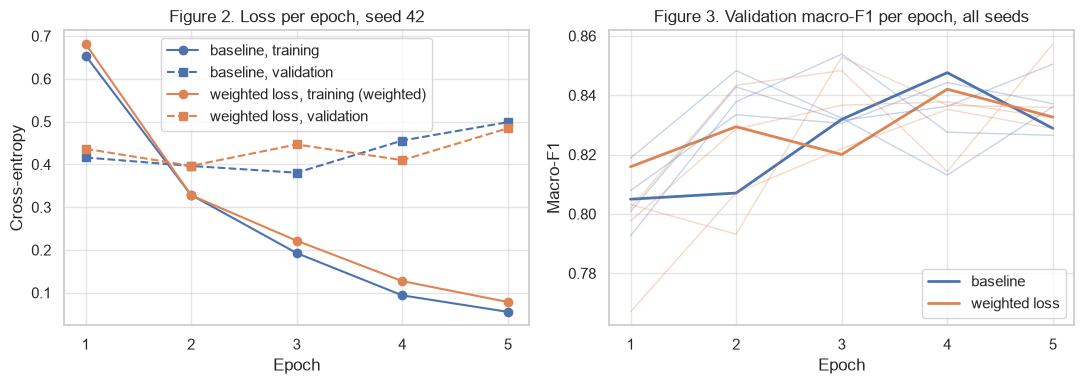

In [33]:
# one color per model, solid for training, dashed for validation
colors = {"baseline": "C0", "weighted loss": "C1"}

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for name, group in main.groupby("model", sort=False):
    axes[0].plot(group["epoch"], group["train_loss"], color=colors[name], marker="o",
                 label=f"{name}, training" + (" (weighted)" if name == "weighted loss" else ""))
    axes[0].plot(group["epoch"], group["validation_loss"], color=colors[name], marker="s",
                 linestyle="--", label=f"{name}, validation")
for (name, seed), group in history.groupby(["model", "seed"], sort=False):
    axes[1].plot(group["epoch"], group["validation_macro_f1"], color=colors[name],
                 alpha=1.0 if seed == MAIN_SEED else 0.3, linewidth=2 if seed == MAIN_SEED else 1,
                 label=name if seed == MAIN_SEED else None)
axes[0].set_title(f"Figure 2. Loss per epoch, seed {MAIN_SEED}")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Cross-entropy")
axes[0].set_xticks(main["epoch"].unique())
axes[0].legend()
axes[1].set_title("Figure 3. Validation macro-F1 per epoch, all seeds")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Macro-F1")
axes[1].set_xticks(main["epoch"].unique())
axes[1].legend()
plt.tight_layout()
plt.show()

**Interpretation:** Figure 2 shows the main run with seed 42. The training loss falls from 0.65 and 0.68 to below 0.1 in five epochs. The validation loss of the baseline is lowest after epoch 3 (0.3805) and rises to 0.4988, for the weighted model it is lowest after epoch 2 (0.3965) and rises to 0.4845. Falling training loss with rising validation loss suggests overfitting. The training losses use different class weights, so only the unweighted validation curves can be compared.

The validation macro-F1 in Figure 3 does not follow the loss. From epoch 2 on it moves between about 0.79 and 0.86 for both configurations and all seeds. My guess is that the model becomes more sure of some wrong answers, which raises the loss without changing many predictions, but I did not test this. The best epochs were 4, 4, 3, 2 and 5 for the baseline and 4, 4, 3, 5 and 4 for the weighted model. Only one run per configuration is best in the last epoch, so more epochs might still help a little in some runs.

## Evaluation and comparison

Both configurations are evaluated once on the test split with the weights of their best validation epoch, for every seed. I fixed the metrics before the first test result. Accuracy is reported for reference only, because most test sentences are neutral. The main metric is macro-F1, the mean of the F1 scores of the three classes, so the rare negative class counts as much as the neutral class. For the research question I add precision, recall and F1 of the negative class, and as floors the constant model and the TF-IDF reference.

In [34]:
def metrics(labels, predicted):
    """Return accuracy, macro-F1 and precision, recall and F1 of the negative class (label 0)."""
    return {"accuracy": accuracy_score(labels, predicted),
            "macro_f1": f1_score(labels, predicted, average="macro"),
            "negative_precision": precision_score(labels, predicted, labels=[0], average="macro",
                                                  zero_division=0),
            "negative_recall": recall_score(labels, predicted, labels=[0], average="macro"),
            "negative_f1": f1_score(labels, predicted, labels=[0], average="macro")}


test = sentences[is_test].copy()
y_test = test["label_id"]
# the test loader keeps the order of the sentences, so predictions and labels belong together
assert (test_labels == y_test.to_numpy()).all()

rows = []
for (name, seed), probabilities in test_probabilities.items():
    rows.append({"model": name, "seed": seed, **metrics(y_test, probabilities.argmax(axis=1))})
per_seed = pd.DataFrame(rows)

summary = per_seed.drop(columns="seed").groupby("model", sort=False).agg(["mean", "std"])
print("Mean and standard deviation over the five seeds:")
summary.round(4)

Mean and standard deviation over the five seeds:


accuracy         macro_f1         negative_precision          \
                  mean     std     mean     std               mean     std   
model                                                                        
baseline        0.8393  0.0045   0.8176  0.0043             0.7386  0.0314   
weighted loss   0.8368  0.0030   0.8191  0.0023             0.7294  0.0192   

              negative_recall         negative_f1          
                         mean     std        mean     std  
model                                                      
baseline               0.8483  0.0385      0.7885  0.0119  
weighted loss          0.8644  0.0249      0.7908  0.0068

In [35]:
# the constant model never predicts "negative", so its negative precision is set to 0
floors = pd.DataFrame({
    "always neutral": metrics(y_test, np.ones(len(test), dtype=int)),
    "TF-IDF + logistic regression": metrics(y_test, reference_predicted[None]),
    "TF-IDF + logistic regression, balanced": metrics(y_test, reference_predicted["balanced"]),
}).T
floors.round(4)

,accuracy,macro_f1,negative_precision,negative_recall,negative_f1
always neutral,0.5886,0.2470,0.0000,0.0000,0.0000
TF-IDF + logistic regression,0.7521,0.6483,0.8611,0.3563,0.5041
"TF-IDF + logistic regression, balanced",0.7424,0.6928,0.6136,0.6207,0.6171


In [36]:
# the same seed means the same head initialization, dropout and batch order,
# so I compare the two configurations seed by seed
paired = per_seed.pivot(index="seed", columns="model")
paired[["macro_f1", "negative_precision", "negative_recall"]].round(4)

macro_f1               negative_precision               negative_recall  \
model baseline weighted loss           baseline weighted loss        baseline   
seed                                                                            
42      0.8208        0.8185             0.7449        0.7064          0.8391   
43      0.8213        0.8183             0.7604        0.7196          0.8391   
44      0.8107        0.8230             0.6875        0.7238          0.8851   
45      0.8189        0.8190             0.7667        0.7423          0.7931   
46      0.8163        0.8170             0.7333        0.7551          0.8851   

                     
model weighted loss  
seed                 
42           0.8851  
43           0.8851  
44           0.8736  
45           0.8276  
46           0.8506

In [37]:
difference = paired.xs("weighted loss", axis=1, level=1) - paired.xs("baseline", axis=1, level=1)
print(f"Seeds where the weighted loss finds more negatives: "
      f"{(difference['negative_recall'] > 0).sum()} of {len(difference)}")
print(f"Seeds where the weighted loss has the higher macro-F1: "
      f"{(difference['macro_f1'] > 0).sum()} of {len(difference)}")
# weighted loss minus baseline, per seed
difference.round(4)

Seeds where the weighted loss finds more negatives: 3 of 5
Seeds where the weighted loss has the higher macro-F1: 3 of 5


,accuracy,macro_f1,negative_precision,negative_recall,negative_f1
seed,,,,,
42,-0.0042,-0.0023,-0.0385,0.0460,-0.0035
43,-0.0083,-0.0029,-0.0408,0.0460,-0.0040
44,0.0069,0.0123,0.0363,-0.0115,0.0178
45,-0.0055,0.0001,-0.0244,0.0345,0.0029
46,-0.0014,0.0007,0.0218,-0.0345,-0.0021


In [38]:
# paired t-test over the five seeds, the null hypothesis is a mean difference of zero
for column in ["macro_f1", "negative_recall"]:
    result = stats.ttest_rel(paired[(column, "weighted loss")], paired[(column, "baseline")])
    print(f"Paired t-test {column}: mean difference {difference[column].mean():.4f}, "
          f"t = {result.statistic:.2f}, p = {result.pvalue:.3f}")

# sign test, it only counts the seeds with a higher value, so it needs no normal distribution
for column in ["macro_f1", "negative_recall"]:
    higher = int((difference[column] > 0).sum())
    result = stats.binomtest(higher, len(difference), 0.5)
    print(f"Sign test {column}: higher in {higher} of {len(difference)} seeds, p = {result.pvalue:.4f}")

Paired t-test macro_f1: mean difference 0.0016, t = 0.56, p = 0.605
Paired t-test negative_recall: mean difference 0.0161, t = 0.98, p = 0.385
Sign test macro_f1: higher in 3 of 5 seeds, p = 1.0000
Sign test negative_recall: higher in 3 of 5 seeds, p = 1.0000


**Interpretation:** Both configurations are clearly above the floors. The constant model reaches macro-F1 0.2470, the TF-IDF reference 0.6483 and with balanced class weights 0.6928, so the baseline is about 0.12 ahead of the best reference.

The baseline reaches a mean test macro-F1 of 0.8176 (standard deviation 0.0043), the weighted model 0.8191 (0.0023). For the baseline the negative precision (0.7386) is below the negative recall (0.8483), so it already flags more sentences as negative than there are. The weighted loss raises the mean negative recall to 0.8644 and lowers the negative precision to 0.7294. The recall is higher in only 3 of 5 seeds, and the macro-F1 is higher in 3 of 5 seeds, in one of them by 0.0001. The mean differences are smaller than the variation between the seeds of one configuration. The paired t-tests give p = 0.605 for macro-F1 and p = 0.385 for the negative recall, and the sign test p = 1.0000 for both, so neither difference is significant at the 5% level. With five pairs the sign test cannot fall below p = 0.0625, and the t-test assumes roughly normal differences, which five values hardly confirm. These tests describe the training variation on this fixed split and do not measure the uncertainty over new training or test samples. With only five seeds I treat the p-values as an exploratory check, not as evidence that the configurations are equivalent. Per seed the weighted model finds on average 1.4 more negative sentences and raises 1.6 more false alarms, a small shift towards the negative class rather than a better or a worse model.

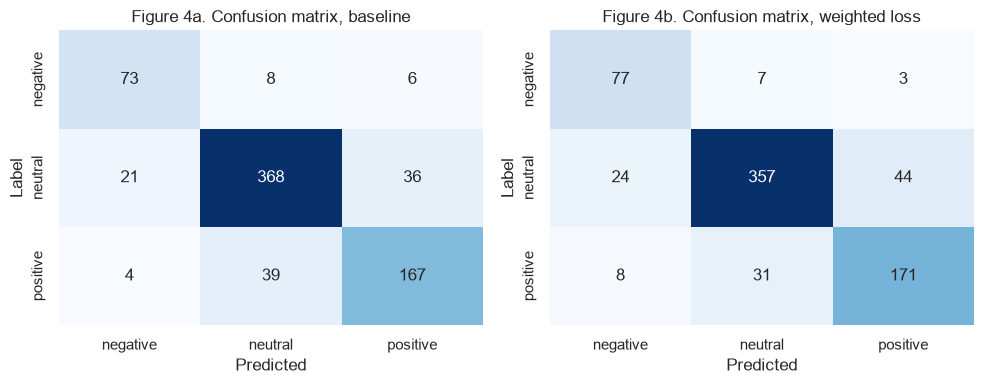

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, name, letter in zip(axes, ["baseline", "weighted loss"], "ab"):
    predicted = test_probabilities[(name, MAIN_SEED)].argmax(axis=1)
    matrix = confusion_matrix(test["label_id"], predicted)
    sns.heatmap(matrix, annot=True, fmt="d", cbar=False, cmap="Blues", ax=ax,
                xticklabels=LABELS, yticklabels=LABELS)
    ax.set_title(f"Figure 4{letter}. Confusion matrix, {name}")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Label")
plt.tight_layout()
plt.show()

**Interpretation:** Figure 4 shows the main run with seed 42. The baseline finds 73 of the 87 negative test sentences, the weighted model 77, and it raises 32 false alarms instead of 25, 24 neutral and 8 positive sentences called negative. The weighted model also shifts the border between neutral and positive. It calls 31 positive sentences neutral instead of 39, but 44 neutral sentences positive instead of 36, so it makes 117 errors in total against 114. Seed 42 was fixed before the training. It is one of the three seeds where the weighted model finds more negative sentences, with the largest gain of 4 sentences, shared with seed 43, and one of the two seeds where its macro-F1 is lower, so Figure 4 shows the trade-off at its clearest, not a typical run.

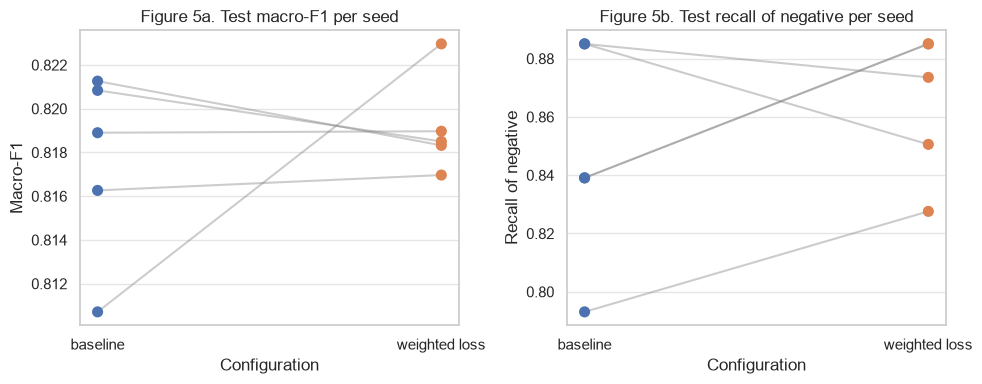

In [40]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
panels = [("a", "macro_f1", "macro-F1", "Macro-F1"),
          ("b", "negative_recall", "recall of negative", "Recall of negative")]
for ax, (letter, column, title, label) in zip(axes, panels):
    sns.stripplot(data=per_seed, x="model", y=column, hue="model", palette=colors, size=8,
                  jitter=False, ax=ax, legend=False)
    for seed, group in per_seed.groupby("seed"):
        ax.plot([0, 1], group.set_index("model").loc[["baseline", "weighted loss"], column],
                color="grey", alpha=0.4)
    ax.set_title(f"Figure 5{letter}. Test {title} per seed")
    ax.set_xlabel("Configuration")
    ax.set_ylabel(label)
plt.tight_layout()
plt.show()

**Interpretation:** Figure 5 shows every seed as one line from the baseline to the weighted model. In Figure 5b three lines go up and two go down, and the lines for seeds 42 and 43 lie exactly on top of each other. The weighted model finds 3 or 4 more of the 87 negative sentences in seeds 42, 43 and 45, and 1 and 3 fewer in seeds 44 and 46. In Figure 5a three lines go up and two go down as well, and the largest change is 0.0123 in seed 44, where the weighted model also has the higher negative precision. The macro-F1 of the baseline spreads over about 0.011 between the seeds, the one of the weighted model over about 0.006, so in my five seeds the weighted loss did not make the results less stable. With only five seeds I do not read either direction as a general property of the weighted loss.

### Results per agreement level

The annotators did not agree on every sentence. If the model makes most of its errors where the annotators also disagreed, this would fit the idea that unclear sentences make the task harder. I compute the accuracy per agreement level for every seed and show the mean and the standard deviation.

In [41]:
rows = []
for (name, seed), probabilities in test_probabilities.items():
    right = probabilities.argmax(axis=1) == test["label_id"].to_numpy()
    for level, group_right in pd.Series(right).groupby(test["agreement"].to_numpy(), observed=True):
        rows.append({"model": name, "seed": seed, "agreement": level, "accuracy": group_right.mean(),
                     "sentences": len(group_right)})
by_level = pd.DataFrame(rows)
by_level["agreement"] = pd.Categorical(by_level["agreement"], sentences["agreement"].cat.categories)
level_table = by_level.groupby(["agreement", "model"], observed=True)["accuracy"].agg(["mean", "std"]).unstack()
level_table["sentences"] = test["agreement"].value_counts()
level_table.round(4)

mean                    std               sentences
model     baseline weighted loss baseline weighted loss          
agreement                                                        
50-65%      0.5896        0.5729   0.0093        0.0266        96
66-74%      0.6500        0.6621   0.0179        0.0254       116
75-99%      0.8629        0.8389   0.0107        0.0075       175
100%        0.9642        0.9719   0.0076        0.0072       335

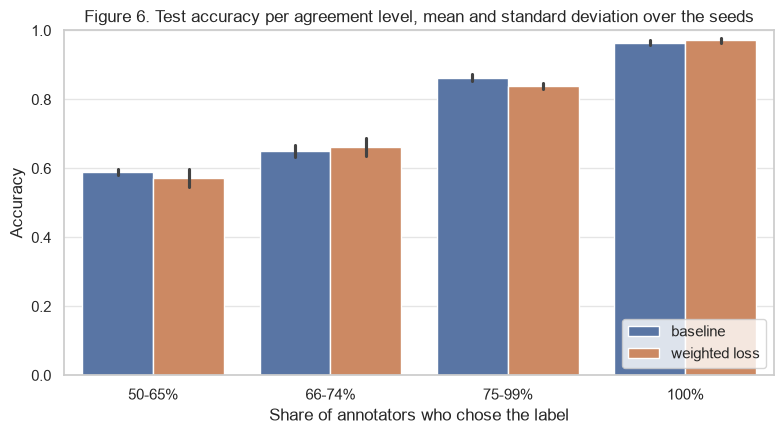

In [42]:
fig, ax = plt.subplots(figsize=(8, 4.5))
sns.barplot(data=by_level, x="agreement", y="accuracy", hue="model", palette=colors,
            errorbar="sd", ax=ax)
ax.set_title("Figure 6. Test accuracy per agreement level, mean and standard deviation over the seeds")
ax.set_xlabel("Share of annotators who chose the label")
ax.set_ylabel("Accuracy")
ax.set_ylim(0, 1)
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

**Interpretation:** Figure 6 shows the clearest pattern of the notebook. On the 335 test sentences where all annotators agreed, the baseline is right on 96.4% on average, on the 96 sentences with only 50-65% agreement on 59.0%. The accuracy falls with every step of lower agreement, for both configurations, so the model has the most trouble exactly where people also disagreed. This is an association and not an isolated effect, because the agreement levels also have a different mix of labels, as the table at the start shows. Some of these errors may be a different reading of an unclear sentence rather than a clear mistake, although the results cannot show which ones. The weighted model is 1.7 percentage points worse on the 50-65% sentences, 1.2 points better on the 66-74% sentences, 2.4 points worse on the 75-99% sentences and 0.8 points better on the sentences with full agreement, with a larger standard deviation on the two lowest levels.

### Error examples

I look at the errors of the baseline in the main run with seed 42, first the ones it is most confident about, then the negative sentences it misses.

In [43]:
baseline_probabilities = test_probabilities[("baseline", MAIN_SEED)]
weighted_probabilities = test_probabilities[("weighted loss", MAIN_SEED)]
test["predicted"] = [LABELS[i] for i in baseline_probabilities.argmax(axis=1)]
test["confidence"] = baseline_probabilities.max(axis=1)
test["weighted_predicted"] = [LABELS[i] for i in weighted_probabilities.argmax(axis=1)]

errors = test[test["predicted"] != test["label"]]
print(f"Baseline errors on the test split, seed {MAIN_SEED}: {len(errors)} of {len(test)}")
errors.groupby(["label", "predicted"]).size().rename("errors").to_frame()

Baseline errors on the test split, seed 42: 114 of 722


errors
label    predicted        
negative neutral         8
         positive        6
neutral  negative       21
         positive       36
positive negative        4
         neutral        39

In [44]:
# sorted by the exact confidence, shown rounded, with the full sentences
columns = ["label", "predicted", "confidence", "weighted_predicted", "agreement", "sentence"]
most_confident = errors.sort_values("confidence", ascending=False)[columns].head(8)
with pd.option_context("display.max_colwidth", None):
    display(most_confident.round({"confidence": 3}))

,label,predicted,confidence,weighted_predicted,agreement,sentence
2876,positive,neutral,0.998,neutral,66-74%,Etteplan targets to employ at least 20 people in Borl+ñnge .
947,positive,neutral,0.997,neutral,50-65%,Finnish mobile operator DNA will function as a subcontractor to Maingate and will be responsible for telecommunications connections .
1009,positive,neutral,0.997,neutral,50-65%,"About Marubeni Marubeni Corporation TSE : 8002 ; ADR : MARUY was established in 1858 , and is a core company of Marubeni Group , one of Japan 's leading general trading houses ."
3989,negative,neutral,0.997,neutral,50-65%,- The Group -¦ s result before taxes was EUR -1.9 ( -3.0 ) million .
1685,positive,neutral,0.996,neutral,66-74%,"We can choose the most efficient , best overall value option for our customers already at the bidding stage ."
1100,positive,neutral,0.996,neutral,50-65%,"The report provides a comprehensive insight into the company , including business structure and operations , executive biographies and key competitors ."
1888,positive,neutral,0.996,neutral,50-65%,CDLI highlights the companies that provided the most comprehensive response to the Carbon Disclosure Project CDP information request .
1596,positive,neutral,0.995,neutral,50-65%,Tekla will implement the renewal in software versions which will be introduced in spring 2011 .


**Interpretation:** In the main run the baseline gets 114 of the 722 test sentences wrong. 75 of them lie between neutral and positive, 36 neutral sentences called positive and 39 positive ones called neutral. The other 39 involve the negative class, 25 false alarms and 14 missed negative sentences. The confidence is the highest softmax probability and is not calibrated. Seven of the eight most confident errors are positive sentences that the model calls neutral with a confidence of 0.995 to 0.998, five of them with only 50-65% agreement. The examples include plans and contracts, such as Etteplan's target to employ at least 20 people in Borlänge. Others describe a company, a report or a disclosure ranking, and one is a statement about bidding. The majority of the annotators read such news as positive, the model as a neutral fact. I would call several of them neutral too, but that is my reading, not proof of wrong labels. The eighth is a negative sentence with a result before taxes of EUR -1.9 million, which both models call neutral. The loss is smaller than the comparison figure of EUR -3.0 million in brackets, and only 50-65% of the annotators chose negative.

In [45]:
# negative sentences that the baseline misses, and what the weighted loss does with them
missed = test[(test["label"] == "negative") & (test["predicted"] != "negative")]
print(f"Negative test sentences: {(test['label'] == 'negative').sum()}")
print(f"Missed by the baseline: {len(missed)}")
print(f"Of these found by the weighted loss: {(missed['weighted_predicted'] == 'negative').sum()}")
with pd.option_context("display.max_colwidth", None):
    display(missed[["predicted", "weighted_predicted", "agreement", "sentence"]])

Negative test sentences: 87
Missed by the baseline: 14
Of these found by the weighted loss: 4


,predicted,weighted_predicted,agreement,sentence
419,positive,positive,50-65%,"Compared with the FTSE 100 index , which rose 36.7 points ( or 0.6 % ) on the day , this was a relative price change of -0.2 % ."
421,positive,positive,66-74%,"Compared with the FTSE 100 index , which rose 94.9 points ( or 1.6 % ) on the day , this was a relative price change of -0.4 % ."
696,positive,positive,100%,"ADP News - Apr 22 , 2009 - Finnish business information systems developer Solteq Oyj HEL : STQ1V said today its net loss widened to EUR 189,000 USD 245,000 for the first quarter of 2009 from EUR 10,000 for the same peri"
3985,positive,negative,100%,Return on investment ROI was 4.1 % compared to 43.8 % in the first half of 2008 .
3989,neutral,neutral,50-65%,- The Group -¦ s result before taxes was EUR -1.9 ( -3.0 ) million .
4006,positive,negative,75-99%,Expense ratio was 102.6 % compared to 92.9 % in the corresponding period in 2005 .
4019,neutral,negative,50-65%,"Myllykoski , with one paper plant in Finland , one in the US and three in Germany , had revenues of EUR286m in the first half of 2010 and an operating loss of EUR12m , Reuters said ."
4115,neutral,neutral,50-65%,"Outokumpu 's steel mill in Tornio , in Finland , is the suspected source ."
4126,neutral,neutral,75-99%,The number of bodily injury cases quadrupled in 2000-2006 .
4141,neutral,neutral,66-74%,"According to Swedish authorities , traces of the very toxic osmium tetroxide have been found on the coast of Per+ñmeri , the Northernmost part of the Gulf of Bothnia ."


**Interpretation:** The baseline misses 14 of the 87 negative test sentences. The weighted model finds 4 of them and loses none of the 73 that the baseline found. Three of the four compare two figures, a return on investment of 4.1% against 43.8%, an expense ratio of 102.6% against 92.9% and sales that slid to EUR 86.4 m from EUR 91.2 m. The fourth reports an operating loss next to revenues of EUR 286 m. Both models miss the other ten. Four of them also contain figures to compare, among them a net loss that widened to EUR 189,000 from EUR 10,000 with full agreement, and two shares that did worse than the FTSE 100 on the day. The other six report bad news without a comparison of two amounts, for example toxic traces on a coast, a quadrupled number of injury cases or a delayed ship, and both models call them neutral. So comparisons between numbers and indirect bad news seem to be a weakness, but I did not test this separately.

## Summary

In this notebook I fine-tuned the pretrained Transformer DistilBERT in PyTorch to classify 4,836 sentences of company news from the Financial PhraseBank as negative, neutral or positive. The baseline uses the normal cross-entropy loss, the experiment a loss that gives the rare negative class more weight, and I trained both with five seeds. The weighted loss raised the mean negative recall from 0.8483 to 0.8644 and the mean macro-F1 from 0.8176 to 0.8191, but it lowered the negative precision from 0.7386 to 0.7294, and all three mean changes are smaller than the variation between the seeds. Both models stayed clearly above the TF-IDF reference (macro-F1 0.6928 with balanced class weights), in the main run most of their errors sit between neutral and positive, and the accuracy is lowest where the annotators disagreed. What surprised me was how small the effect of the weighted loss was, and the two-sided paired t-tests (p = 0.605 for macro-F1, p = 0.385 for the negative recall) did not detect a difference over the five seeds on this fixed split. Other challenges were signs of overfitting after epoch 2 or 3 and sentence templates with other numbers that had to stay in one split.